In [40]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


import warnings
warnings.filterwarnings('ignore') 


In [41]:
# Load Dataset
df = pd.read_csv('/Users/jestin/Documents/data scince/datasets  2/Bank+Customer+Churn (1)/Bank_Churn.csv') # make sure the file is in the same directory
print(df.shape)
df.head()


(10000, 13)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
#  removing duplicates
df.drop_duplicates(inplace=True)


# Check missing values
print(df.isnull().sum())
print()
print(f"duplicates : {df.duplicated().sum()}")  

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

duplicates : 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [5]:
# Drop unnecessary columns
df.drop([ 'CustomerId', 'Surname'], axis=1, inplace=True)

In [6]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


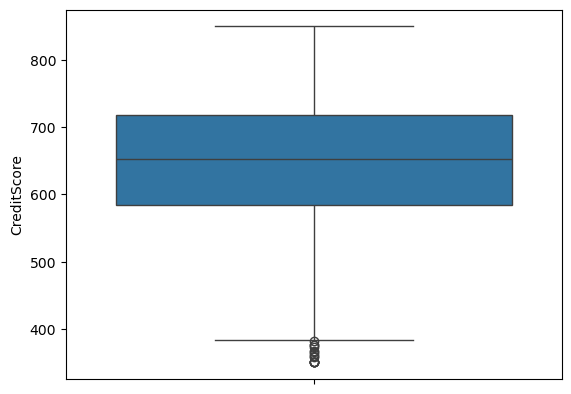

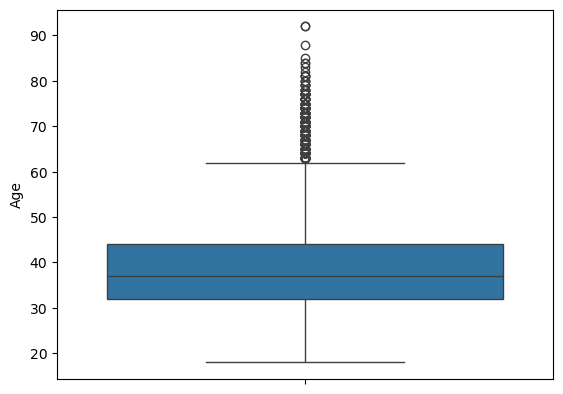

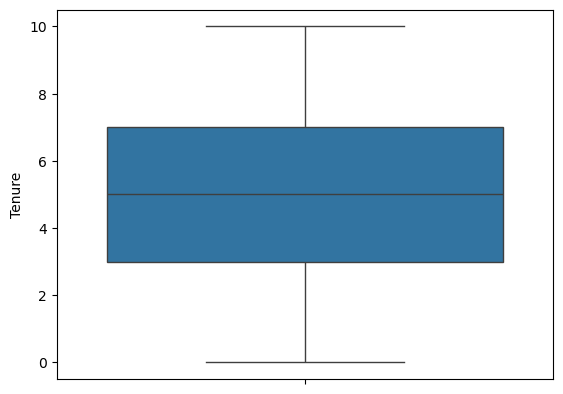

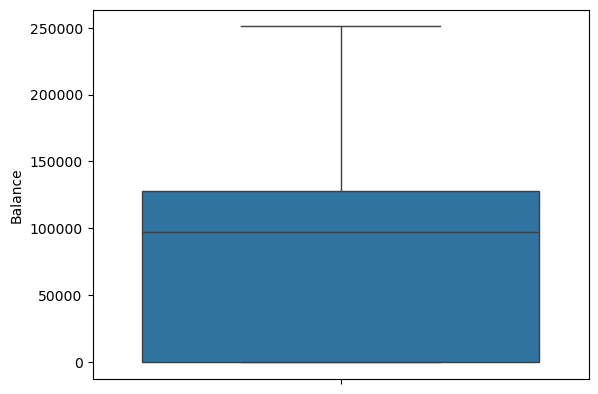

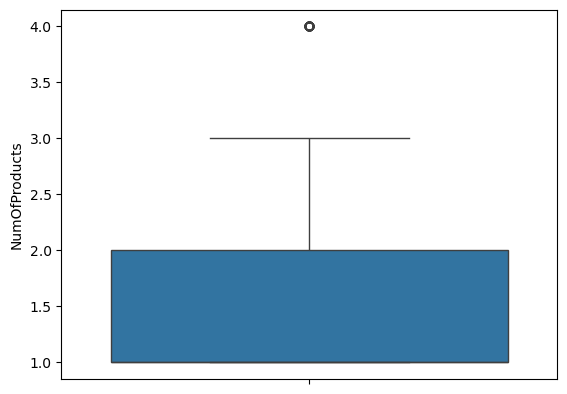

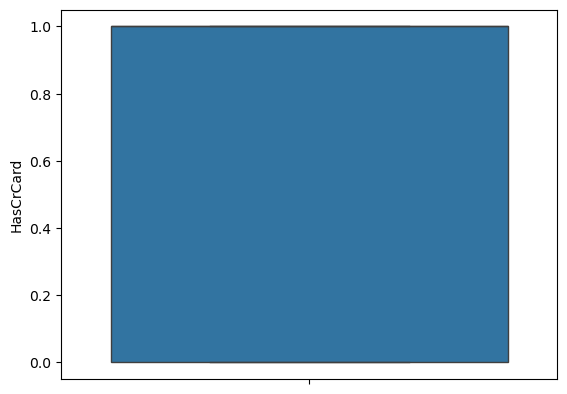

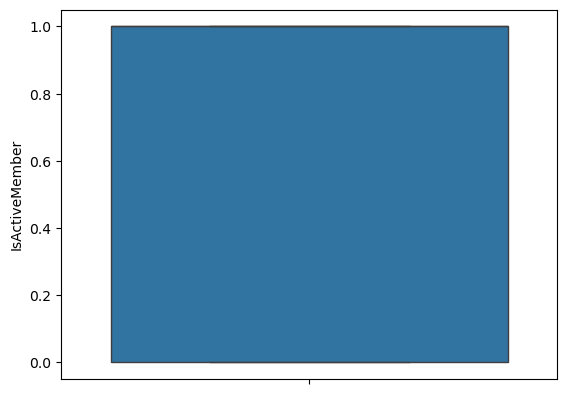

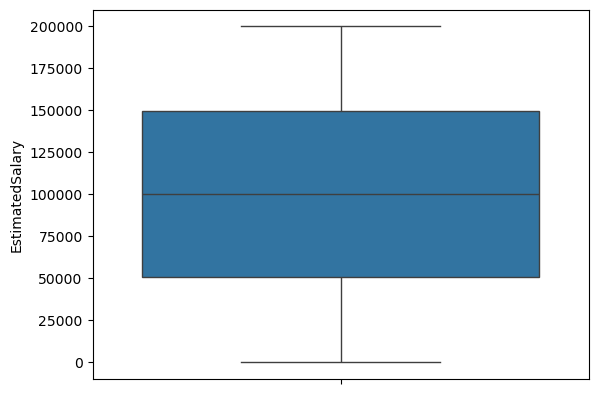

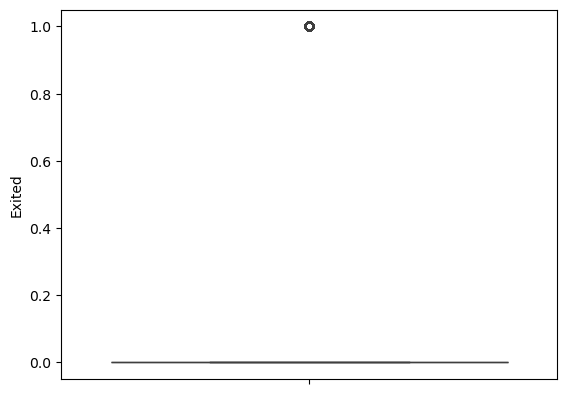

In [7]:
# checking the outliers
def boxplots(col):
    sns.boxplot(df[col])
    plt.show()

for i in list(df.select_dtypes(exclude=['object']).columns)[0:]:
    boxplots(i)

# Encoding method

In [8]:
# Encode categorical variables
# caltegorical variable ['Geography',Gender]
from sklearn.preprocessing import LabelEncoder

In [9]:
# Applying onehot encoder for Gender cause not in order 

df = pd.get_dummies(df,columns = ['Gender'],drop_first = True)
df = pd.get_dummies(df,columns = ['Geography'],drop_first = True)

# corelation

In [10]:
df.corr().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
CreditScore,1.00,-0.00,0.00,0.01,0.01,-0.01,0.03,-0.00,-0.03,-0.00,0.01,0.00
Age,-0.00,1.00,-0.01,0.03,-0.03,-0.01,0.09,-0.01,0.29,-0.03,0.05,-0.00
Tenure,0.00,-0.01,1.00,-0.01,0.01,0.02,-0.03,0.01,-0.01,0.01,-0.00,0.00
Balance,0.01,0.03,-0.01,1.00,-0.30,-0.01,-0.01,0.01,0.12,0.01,0.40,-0.13
NumOfProducts,0.01,-0.03,0.01,-0.30,1.00,0.00,0.01,0.01,-0.05,-0.02,-0.01,0.01
HasCrCard,-0.01,-0.01,0.02,-0.01,0.00,1.00,-0.01,-0.01,-0.01,0.01,0.01,-0.01
IsActiveMember,0.03,0.09,-0.03,-0.01,0.01,-0.01,1.00,-0.01,-0.16,0.02,-0.02,0.02
EstimatedSalary,-0.00,-0.01,0.01,0.01,0.01,-0.01,-0.01,1.00,0.01,-0.01,0.01,-0.01
Exited,-0.03,0.29,-0.01,0.12,-0.05,-0.01,-0.16,0.01,1.00,-0.11,0.17,-0.05
Gender_Male,-0.00,-0.03,0.01,0.01,-0.02,0.01,0.02,-0.01,-0.11,1.00,-0.02,0.02


In [11]:
# using heatmap

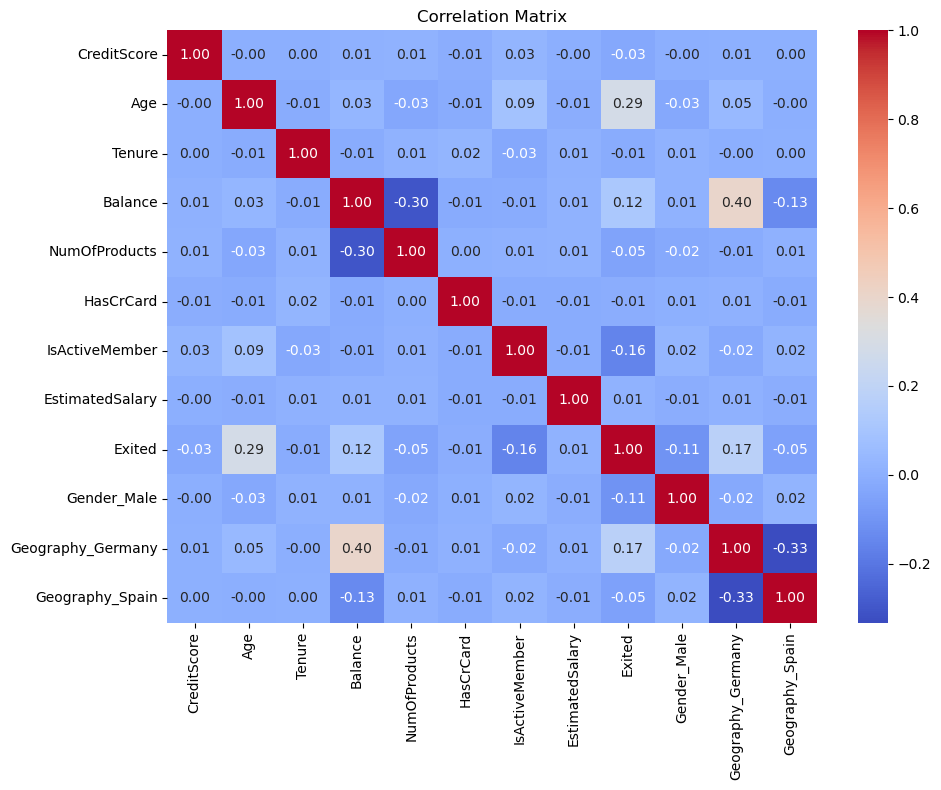

In [12]:
# Correlation heatmap

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# spliting the data into independent and dependent variable

In [35]:
#seperating it into features and target

x = df.drop('Exited',axis =1)
y = df['Exited']

In [14]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True


In [15]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [37]:
# Scale numerical features
scaler = StandardScaler()
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
x[num_features] = scaler.fit_transform(x[num_features])


In [17]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,False,False,True
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,False,False,True


In [18]:
 y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

# imbalance Treatment

In [19]:
# using smote method
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_smote, y_smote = smote.fit_resample(x,y)

In [20]:
print("original data :", y.value_counts())
print()
print("balanced data :", y_smote.value_counts())

original data : Exited
0    7963
1    2037
Name: count, dtype: int64

balanced data : Exited
1    7963
0    7963
Name: count, dtype: int64


In [21]:
# Split data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_smote,y_smote, test_size=0.2, random_state=42)



# model Building 

In [22]:
# random Forest

rf = RandomForestClassifier(n_estimators=60,random_state=7)
rf = rf.fit(x_train, y_train)

In [23]:
y_pred_train_rf = rf.predict(x_train)
y_pred_test_rf = rf.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_test_rf)  
print(classification_report(y_train, y_pred_train_rf))
print()
print(classification_report(y_test, y_pred_test_rf))
print("********************")
print("Training Acc :", accuracy_score(y_train, y_pred_train_rf))
print()
print("Test Acc :",accuracy_score(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6330
           1       1.00      1.00      1.00      6410

    accuracy                           1.00     12740
   macro avg       1.00      1.00      1.00     12740
weighted avg       1.00      1.00      1.00     12740


              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1633
           1       0.89      0.89      0.89      1553

    accuracy                           0.89      3186
   macro avg       0.89      0.89      0.89      3186
weighted avg       0.89      0.89      0.89      3186

********************
Training Acc : 1.0

Test Acc : 0.8920276208411801


In [24]:
# Xg boost

from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False,random_state=42)
xgb = xgb.fit(x_train, y_train)


In [25]:
y_pred_train_xgb = xgb.predict(x_train)
y_pred_test_xgb = xgb.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_test_xgb)  
print(classification_report(y_train, y_pred_train_xgb))
print()
print(classification_report(y_test, y_pred_test_xgb))
print("********************")
print("Training Acc :", accuracy_score(y_train, y_pred_train_xgb))
print()
print("Test Acc :",accuracy_score(y_test, y_pred_test_xgb))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6330
           1       0.98      0.94      0.96      6410

    accuracy                           0.96     12740
   macro avg       0.96      0.96      0.96     12740
weighted avg       0.96      0.96      0.96     12740


              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1633
           1       0.91      0.88      0.89      1553

    accuracy                           0.90      3186
   macro avg       0.90      0.90      0.90      3186
weighted avg       0.90      0.90      0.90      3186

********************
Training Acc : 0.960204081632653

Test Acc : 0.8995605775266792


In [26]:
# logistic regression

from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(random_state = 7)
lr = logit.fit(x_train, y_train)
y_pred_train_lr = lr.predict(x_train)
y_pred_test_lr = lr.predict(x_test)
accuracy_lr = accuracy_score(y_test, y_pred_test_lr)  

print(classification_report(y_train, y_pred_train_lr))
print()
print(classification_report(y_test, y_pred_test_lr))
print("********************")
print("Training Acc :", accuracy_score(y_train, y_pred_train_lr))
print()
print("Test Acc :",accuracy_score(y_test, y_pred_test_lr))

              precision    recall  f1-score   support

           0       0.73      0.72      0.73      6330
           1       0.73      0.73      0.73      6410

    accuracy                           0.73     12740
   macro avg       0.73      0.73      0.73     12740
weighted avg       0.73      0.73      0.73     12740


              precision    recall  f1-score   support

           0       0.73      0.72      0.73      1633
           1       0.71      0.72      0.72      1553

    accuracy                           0.72      3186
   macro avg       0.72      0.72      0.72      3186
weighted avg       0.72      0.72      0.72      3186

********************
Training Acc : 0.7276295133437991

Test Acc : 0.7203389830508474


In [27]:
# DecisionTree

dtree = DecisionTreeClassifier()
dt = dtree.fit(x_train, y_train)
y_pred_dt_train = dtree.predict(x_train)
y_pred_dt_test = dtree.predict(x_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt_test)  

print(classification_report(y_train, y_pred_dt_train))
print()
print(classification_report(y_test, y_pred_dt_test))
print("********************")
print("Training Acc :", accuracy_score(y_train, y_pred_dt_train))
print()
print("Test Acc :",accuracy_score(y_test, y_pred_dt_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6330
           1       1.00      1.00      1.00      6410

    accuracy                           1.00     12740
   macro avg       1.00      1.00      1.00     12740
weighted avg       1.00      1.00      1.00     12740


              precision    recall  f1-score   support

           0       0.84      0.81      0.82      1633
           1       0.81      0.83      0.82      1553

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.82      3186
weighted avg       0.82      0.82      0.82      3186

********************
Training Acc : 1.0

Test Acc : 0.8210922787193974


In [28]:
# GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

gdboost = GradientBoostingClassifier()
gd = gdboost.fit(x_train, y_train)
y_pred_gd_test = gdboost.predict(x_test)
y_pred_gd_train = gdboost.predict(x_train)
accuracy_gd = accuracy_score(y_test, y_pred_gd_test)  

print(classification_report(y_train, y_pred_gd_train))
print()
print(classification_report(y_test, y_pred_gd_test))
print("********************")
print("Training Acc :", accuracy_score(y_train, y_pred_gd_train))
print()
print("Test Acc :",accuracy_score(y_test, y_pred_gd_test))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      6330
           1       0.88      0.84      0.86      6410

    accuracy                           0.86     12740
   macro avg       0.86      0.86      0.86     12740
weighted avg       0.86      0.86      0.86     12740


              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1633
           1       0.86      0.83      0.85      1553

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186

********************
Training Acc : 0.8612244897959184

Test Acc : 0.8534212178279975


In [29]:
# BaggingClassifier
bagging = BaggingClassifier()
bg = bagging.fit(x_train, y_train)
y_pred_bg_test = bg.predict(x_test)
y_pred_bg_train = bg.predict(x_train)
accuracy_bg = accuracy_score(y_test, y_pred_bg_test)  

print(classification_report(y_train, y_pred_bg_train))
print()
print(classification_report(y_test, y_pred_bg_test))
print("********************")
print("Training Acc :", accuracy_score(y_train, y_pred_bg_train))
print()
print("Test Acc :",accuracy_score(y_test, y_pred_bg_test))



              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6330
           1       1.00      0.99      0.99      6410

    accuracy                           0.99     12740
   macro avg       0.99      0.99      0.99     12740
weighted avg       0.99      0.99      0.99     12740


              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1633
           1       0.87      0.85      0.86      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186

********************
Training Acc : 0.9932496075353218

Test Acc : 0.8659761456371626


In [30]:
list1 = ['Random forest','XG BOOST','Logistic Regression','Decision Tree','GradientBoosting','Bagging']

list2 = [accuracy_rf,accuracy_xgb,accuracy_lr,accuracy_dt,accuracy_gd, accuracy_bg]
list3 = [rf,xgb,logit,dtree,gdboost,bagging]


df_accuracy = pd.DataFrame({'Model Name':list1, 'Accuracy':list2})
print(df_accuracy)


            Model Name  Accuracy
0        Random forest  0.892028
1             XG BOOST  0.899561
2  Logistic Regression  0.720339
3        Decision Tree  0.821092
4     GradientBoosting  0.853421
5              Bagging  0.865976


Axes(0.125,0.11;0.775x0.77)


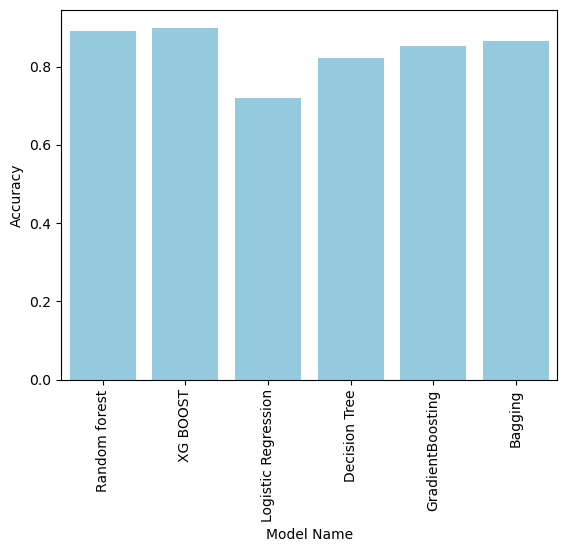

In [38]:
charts = sns.barplot(x='Model Name', y='Accuracy', data=df_accuracy,color = 'skyblue')
charts.set_xticklabels(charts.get_xticklabels(), rotation=90)
print(charts)

# cross validation approach

In [32]:
x_train.shape

(12740, 11)

In [33]:
y_train.shape

(12740,)

In [34]:
# to check the stability of the models performance


from sklearn.model_selection import cross_val_score  

accuracy_rf = cross_val_score(rf, x_train, y_train, cv=10)  
accuracy_xgb = cross_val_score(xgb, x_train, y_train, cv=10)  
accuracy_lr = cross_val_score(lr, x_train, y_train, cv=10)  
accuracy_dt = cross_val_score(dt, x_train, y_train, cv=10)  
accuracy_gd = cross_val_score(gd, x_train, y_train, cv=10)  
accuracy_bg = cross_val_score(bg, x_train, y_train, cv=10)  

# Print mean accuracy  
print(f"Mean Random Forest Cross-Validation: {accuracy_rf.mean()}")  
print(f"Mean XGBoost Cross-Validation: {accuracy_xgb.mean()}")  
print(f"Mean Logistic Regression Cross-Validation: {accuracy_lr.mean()}")  
print(f"Mean Decision Tree Cross-Validation: {accuracy_dt.mean()}")  
print(f"Mean Gradient Descent Cross-Validation: {accuracy_gd.mean()}")  
print(f"Mean Bagging Classifier Cross-Validation: {accuracy_bg.mean()}")  

Mean Random Forest Cross-Validation: 0.8875981161695448
Mean XGBoost Cross-Validation: 0.8944270015698587
Mean Logistic Regression Cross-Validation: 0.7276295133437991
Mean Decision Tree Cross-Validation: 0.822291993720565
Mean Gradient Descent Cross-Validation: 0.8552590266875981
Mean Bagging Classifier Cross-Validation: 0.8640502354788069
